In [49]:
import matplotlib.pyplot as plt
import numpy as np

def plotar_grafo_normalizado(np_array, title, xlabel):
    # Conta os valores
    contagem = np_array.value_counts()

    # Normaliza
    proporcao = contagem / contagem.sum()

    # Plota
    plt.figure(figsize=(10, 6))
    proporcao.plot(kind='bar', color='skyblue', edgecolor='black')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Proporção dos Casos')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
    
def checar_nan(np_array, nome_coluna="Coluna"):
    total = len(np_array)
    n_nan = np_array.isna().sum()
    perc_nan = (n_nan / total) * 100 if total > 0 else 0
    
    if n_nan > 0:
        print(f"Atenção: A coluna '{nome_coluna}' contém {n_nan} valores NaN.")
        print(f"Isso representa {perc_nan:.2f}% do total de {total} registros.")
    else:
        print(f"A coluna '{nome_coluna}' não contém valores NaN.")

    


In [3]:
import pandas as pd
import os

# Diretório onde estão os arquivos CSV
caminho_diretorio = "data/csv_format/"
arquivos_csv = [f for f in os.listdir(caminho_diretorio) if f.endswith(".csv")]
dfs = [pd.read_csv(os.path.join(caminho_diretorio, arquivo), delimiter=',', dtype=str).assign(arquivo=arquivo) for arquivo in arquivos_csv]
df = pd.concat(dfs, ignore_index=True)
df.head()


,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,ANT_RETRO,BAC_APOS_6,TRANSF,UF_TRANSF,MUN_TRANSF,arquivo
0,0,2,A169,2001-01-04,2001,41,410420,1356,2001-01-04,1961,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
1,1,2,A169,2001-02-20,2001,41,410690,1356,2001-02-20,1974,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
2,2,2,A169,2001-01-12,2001,26,260570,1506,2001-01-12,1960,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
3,3,2,A169,2001-02-23,2001,15,150140,1484,2001-02-23,1975,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv
4,4,2,A169,2001-01-05,2001,13,130120,0,2001-01-05,1975,...,0,0,0,0,0,0,0,NaN,NaN,TUBEBR01.csv


In [4]:
df['NU_ANO'] = pd.to_numeric(df['NU_ANO'], errors='coerce')
df_filtra_ano = df[df['NU_ANO'].between(2019, 2025)]

df_filtra_ano.shape

(506195, 99)

In [6]:
df_filtra_ano.columns

Index(['Unnamed: 0', 'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO',
       'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'DT_DIAG', 'ANO_NASC',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF',
       'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'NDUPLIC_N', 'IN_VINCULA',
       'DT_DIGITA', 'DT_TRANSUS', 'DT_TRANSDM', 'DT_TRANSSM', 'DT_TRANSRM',
       'DT_TRANSRS', 'DT_TRANSSE', 'CS_FLXRET', 'FLXRECEBI', 'MIGRADO_W',
       'ID_OCUPA_N', 'TRATAMENTO', 'INSTITUCIO', 'RAIOX_TORA', 'TESTE_TUBE',
       'FORMA', 'EXTRAPU1_N', 'EXTRAPU2_N', 'EXTRAPUL_O', 'AGRAVAIDS',
       'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'AGRAVOUTDE',
       'BACILOSC_E', 'BACILOS_E2', 'BACILOSC_O', 'CULTURA_ES', 'CULTURA_OU',
       'HIV', 'HISTOPATOL', 'DT_INIC_TR', 'RIFAMPICIN', 'ISONIAZIDA',
       'ETAMBUTOL', 'ESTREPTOMI', 'PIRAZINAMI', 'ETIONAMIDA', 'OUTRAS',
       'OUTRAS_DES', 'TRAT_SUPER', 'NU_CONTATO', 'DOENCA_TRA', 'SG_UF_AT',
       'ID_MUNIC_A', 'DT_NOTI_AT', 'SG_

O campo a seguir que sinaliza se houve óbito ou cura:

### 🔹 `SITUA_ENCE` — Situação de encerramento

Conforme o dicionário de dados do SINAN para tuberculose:

| Valor | Descrição                         | 
|-------|-----------------------------------|
| 1     | Cura                              |
| 2     | Abandono                          |
| 3     | Óbito por Tuberculose             |
| 4     | Óbito por outras causas           |
| 5     | Transferência                     |
| 6     | Mudança de diagnóstico            |
| 7     | TB resistente (TB-DR)             |
| 8     | Mudança de esquema terapêutico    |
| 9     | Falência                          |
| 10    | Abandono primário                 |

In [8]:
df_filtra_ano['SITUA_ENCE'].value_counts()


SITUA_ENCE
 1    298620
 2     73360
 5     35303
 4     20546
 3     20026
 6     10555
 7      5321
10      5038
 8      4341
1       1836
2        853
 9       336
5        294
3        180
4        140
7        102
0         36
03        35
8         27
04        13
9          7
-1         1
Name: count, dtype: int64

In [ ]:
def agrupar_situacao(codigo):
    try:
        if pd.isna(codigo):
            return 2
        codigo = int(float(codigo))  # converte para int, mesmo que venha como float tipo 1.0
        if codigo == 1:
            return 0
        elif codigo == 3:
            return 1
        else:
            return 2
    except:
        print(f'Erro ao processar: {codigo}')
        return 'Outro'


df_filtra_ano.loc[:, 'SITUACAO_AGRUPADA'] = df_filtra_ano['SITUA_ENCE'].apply(agrupar_situacao)

plotar_grafo(df_filtra_ano['SITUA_ENCE'], "", xlabel)


/tmp/ipykernel_10520/3751330172.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_filtra_ano.loc[:, 'SITUACAO_AGRUPADA'] = df_filtra_ano['SITUA_ENCE'].apply(agrupar_situacao)


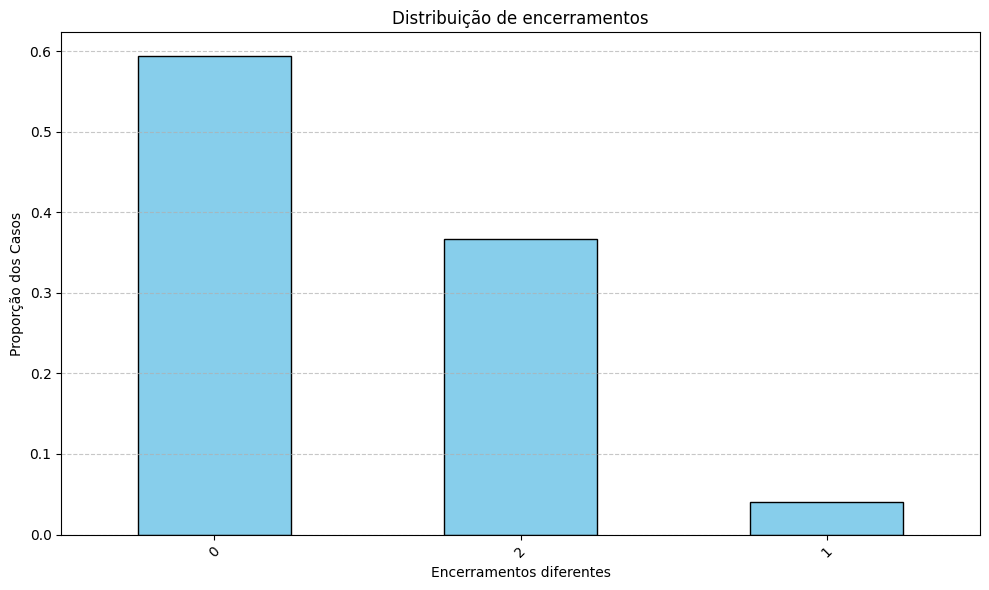

In [20]:
plotar_grafo_normalizado(df_filtra_ano['SITUACAO_AGRUPADA'], "Distribuição de encerramentos", "Encerramentos diferentes")

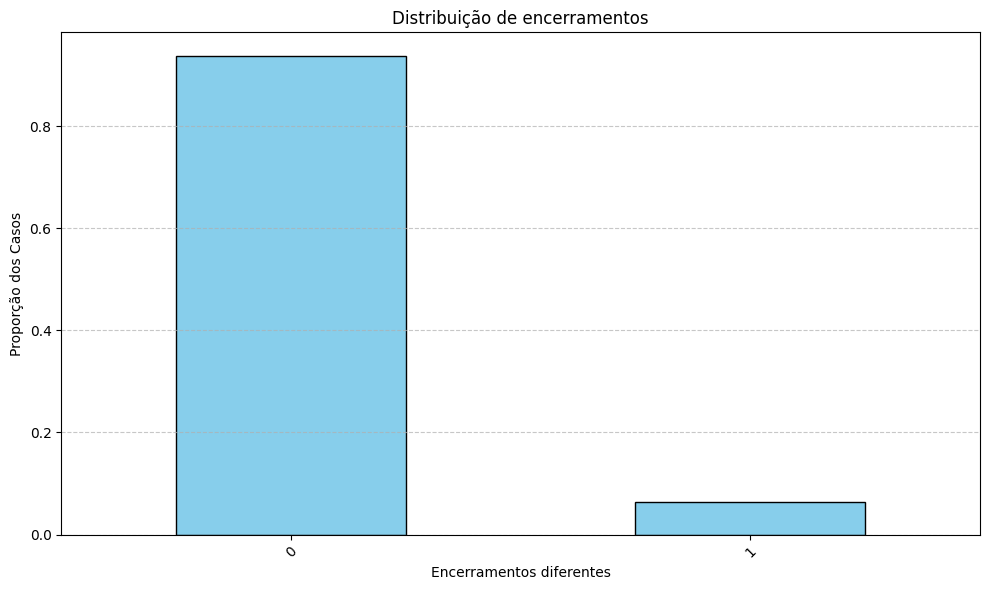

In [ ]:
df_filtra_fim = df_filtra_ano[df_filtra_ano['SITUACAO_AGRUPADA'] != 2]

plotar_grafo_normalizado(df_filtra_fim['SITUACAO_AGRUPADA'], "Distribuição de encerramentos", "Encerramentos diferentes")

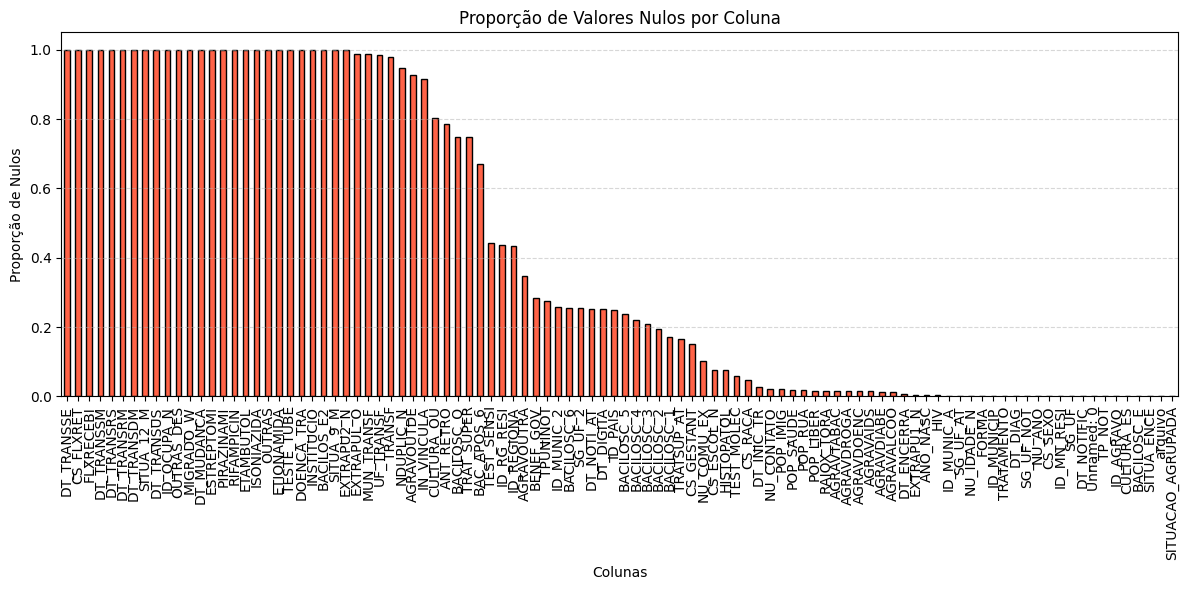

In [23]:
# a gente tentou cortar as colunas com mais componentes nulos

import matplotlib.pyplot as plt

# Calcula a proporção de valores nulos por coluna
null_ratios = df_filtra_fim.isna().mean()

# Plota o histograma (gráfico de barras)
plt.figure(figsize=(12, 6))
null_ratios.sort_values(ascending=False).plot(kind='bar', color='tomato', edgecolor='black')

plt.title('Proporção de Valores Nulos por Coluna')
plt.xlabel('Colunas')
plt.ylabel('Proporção de Nulos')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


In [25]:
# Define the threshold (e.g., 50% empty values)
threshold = 0.6

# Calculate the proportion of empty (or NaN) values per column
empty_ratio = df_filtra_fim.isna().mean()

# Select columns where the proportion of empty values exceeds the threshold
columns_to_drop = empty_ratio[empty_ratio > threshold].index

# Drop those columns
df_cleaned_columns = df_filtra_fim.copy()
df_cleaned_columns = df_cleaned_columns.drop(columns=columns_to_drop)

# Display the cleaned dataframe
df_cleaned_columns.head()

,Unnamed: 0,TP_NOT,ID_AGRAVO,DT_NOTIFIC,NU_ANO,SG_UF_NOT,ID_MUNICIP,ID_REGIONA,DT_DIAG,ANO_NASC,...,POP_RUA,POP_SAUDE,POP_IMIG,BENEF_GOV,AGRAVDROGA,AGRAVTABAC,TEST_MOLEC,TEST_SENSI,arquivo,SITUACAO_AGRUPADA
180124,92859,2,A169,2020-03-18,2020,35,355030,0,2002-02-10,1964,...,2,2,2,0,1,2,5,7,TUBEBR02.csv,0
715334,86768,2,A169,2019-10-02,2019,35,355030,0,2008-10-01,1962,...,2,2,2,0,2,1,1,5,TUBEBR08.csv,0
801654,86319,2,A169,2019-01-02,2019,35,355030,0,2009-12-27,1970,...,1,2,2,0,2,1,1,7,TUBEBR09.csv,1
801655,86320,2,A169,2020-05-26,2020,35,355030,0,2009-06-15,1982,...,2,2,3,0,2,2,1,7,TUBEBR09.csv,0
887037,85381,2,A169,2019-04-18,2019,35,355030,0,2010-08-19,1983,...,2,2,2,0,1,1,1,5,TUBEBR10.csv,0


Agora vamos olhar coluna por coluna

In [26]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO',
       'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'DT_DIAG', 'ANO_NASC',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF',
       'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'DT_DIGITA', 'TRATAMENTO',
       'RAIOX_TORA', 'FORMA', 'EXTRAPU1_N', 'AGRAVAIDS', 'AGRAVALCOO',
       'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'BACILOSC_E', 'CULTURA_ES',
       'HIV', 'HISTOPATOL', 'DT_INIC_TR', 'NU_CONTATO', 'SG_UF_AT',
       'ID_MUNIC_A', 'DT_NOTI_AT', 'SG_UF_2', 'ID_MUNIC_2', 'BACILOSC_1',
       'BACILOSC_2', 'BACILOSC_3', 'BACILOSC_4', 'BACILOSC_5', 'BACILOSC_6',
       'TRATSUP_AT', 'NU_COMU_EX', 'SITUA_ENCE', 'DT_ENCERRA', 'TPUNINOT',
       'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV',
       'AGRAVDROGA', 'AGRAVTABAC', 'TEST_MOLEC', 'TEST_SENSI', 'arquivo',
       'SITUACAO_AGRUPADA'],
      dtype='object')

Nome do campo Tipo Categorias Descrição DBF <br>
Tipo de Notificação varchar2(1) <br>
1 – Negativa <br>
2 – Individual <br>
3 – Surto <br>
4 – Agregado <br>
Identifica o tipo da notificação TP_NOT

In [28]:
df_cleaned_columns["TP_NOT"].value_counts()

TP_NOT
2    320697
Name: count, dtype: int64

In [30]:
df_cleaned_columns = df_cleaned_columns.drop(columns=["TP_NOT"])

Agravo varchar2(4) <br>
Tabela de agravos do sistema com códigos (classificação 
internacional de doenças – CID 10) e nomes dos agravos 
classificados como notificação compulsória (nacional, 
estadual ou municipal) e as síndromes (febre hemorragia 
aguda; respiratória aguda; diarréia aguda; sanguinolenta; 
neurológica aguda; insuficiência renal aguda; outras 
síndromes. <br>
Nome e código do agravo notificado 
segundo CID-10 (Centro Colaborador da 
OMS para a Classificação de Doenças 
em Português) <br>
ID_AGRAVO

In [32]:
df_cleaned_columns['ID_AGRAVO'].value_counts()


ID_AGRAVO
A169    320696
A16.         1
Name: count, dtype: int64

In [34]:
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_AGRAVO"])

Data da Notificação<br> date <br>dd/mm/aaaa Data de preenchimento da ficha de 
notificação. <br>DT_NOTIFIC 

In [40]:
df_cleaned_columns['SG_UF_NOT'].value_counts()

SG_UF_NOT
35    80347
33    50142
26    19950
43    19095
15    18717
29    16415
31    14478
13    13577
23    13525
21    10079
41     8681
42     7166
24     5119
50     4876
51     4668
32     4591
25     4488
52     4138
27     3650
28     3650
22     2954
12     2726
11     2421
14     1616
16     1506
53     1277
17      845
Name: count, dtype: int64

In [37]:
# Decidimos remover, porque repete a informação de ano que já extraímos
df_cleaned_columns = df_cleaned_columns.drop(columns=["DT_NOTIFIC"])

UF de Notificação<br>varchar2(2)<br> Tabela com Códigos e siglas padronizados pelo IBGE <br>
Sigla da Unidade Federativa onde está 
localizada a unidade de saúde (ou outra 
fonte notificadora) que realizou a 
notificação. A sigla é uma variável que 
está associada ao código na tabela. <br>
SG_UF_NOT

In [52]:
df_cleaned_columns["SG_UF_NOT"].value_counts()

SG_UF_NOT
35    80347
33    50142
26    19950
43    19095
15    18717
29    16415
31    14478
13    13577
23    13525
21    10079
41     8681
42     7166
24     5119
50     4876
51     4668
32     4591
25     4488
52     4138
27     3650
28     3650
22     2954
12     2726
11     2421
14     1616
16     1506
53     1277
17      845
Name: count, dtype: int64

In [55]:
checar_nan(df_cleaned_columns["SG_UF_NOT"], "SG_UF_NOT")

checar_nan(df_cleaned_columns["REGIAO"], "REGIAO")

A coluna 'SG_UF_NOT' não contém valores NaN.
Atenção: A coluna 'REGIAO' contém 320697 valores NaN.
Isso representa 100.00% do total de 320697 registros.


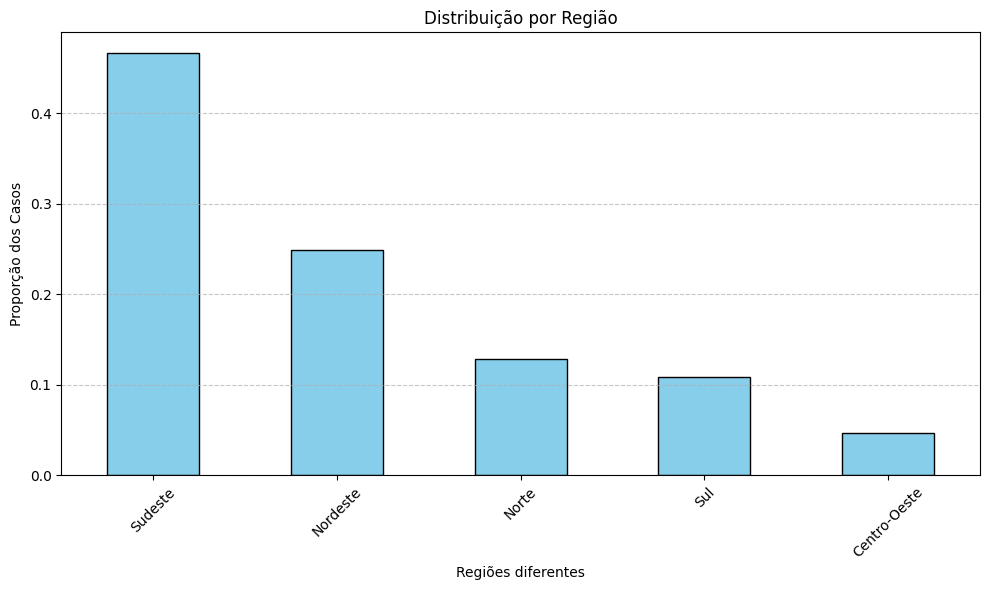

In [56]:
# Dicionário de UFs por região
regioes = {
    # Norte
    12: 'Norte', 16: 'Norte', 13: 'Norte', 11: 'Norte', 14: 'Norte',
    15: 'Norte', 17: 'Norte',

    # Nordeste
    21: 'Nordeste', 22: 'Nordeste', 23: 'Nordeste', 24: 'Nordeste',
    25: 'Nordeste', 26: 'Nordeste', 27: 'Nordeste', 28: 'Nordeste',
    29: 'Nordeste',

    # Centro-Oeste
    50: 'Centro-Oeste', 51: 'Centro-Oeste', 52: 'Centro-Oeste', 53: 'Centro-Oeste',

    # Sudeste
    31: 'Sudeste', 32: 'Sudeste', 33: 'Sudeste', 35: 'Sudeste',

    # Sul
    41: 'Sul', 42: 'Sul', 43: 'Sul'
}

# Cria uma nova coluna com o nome da região
df_cleaned_columns["SG_UF_NOT"] = df_cleaned_columns["SG_UF_NOT"].astype(int)
df_cleaned_columns["REGIAO"] = df_cleaned_columns["SG_UF_NOT"].map(regioes)

# Plota gráfico de barras normalizado
plotar_grafo_normalizado(df_cleaned_columns['REGIAO'], "Distribuição por Região", "Regiões diferentes")


In [ ]:
#Decidimos dar drop porque criamos uma outra coluna simplificada, para as regiões do país
df_cleaned_columns = df_cleaned_columns.drop(columns=["SG_UF_NOT"])

Município de Notificação <br>varchar2(6) <br>Tabela com Código e nome dos municípios do cadastro do 
IBGE (tabela municipi.dbf) <br>
Código do município onde está 
localizada a unidade de saúde (ou outra 
fonte notificadora) que realizou a 
notificação. O nome está associado ao 
código na tabela de municípios. <br>
ID_MUNICIP 

In [60]:
df_cleaned_columns["ID_MUNICIP"].value_counts()

ID_MUNICIP
355030    29362
330455    26873
130260    10189
261160     7735
150140     5949
          ...  
411360        1
510880        1
421730        1
411470        1
430755        1
Name: count, Length: 4785, dtype: int64

In [61]:
# Decidimos dar drop porque não pretendemos dar uma granularidade tão grande para dados geográficos
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_MUNICIP"])

(campo interno)<br> varchar2(4)<br>  Campo com código da regional de saúde da tabela de 
município do sistema  <br> 
Regional de saúde onde está localizado 
o município da unidade de saúde ou 
outra fonte notificadora <br> 
ID_REGIONA 

In [64]:
df_cleaned_columns["ID_REGIONA"].value_counts()

ID_REGIONA
 149    21142
 148    16082
 558    13257
 159    13094
 138    11835
        ...  
1975        1
1385        1
194         1
186         1
189         1
Name: count, Length: 132, dtype: int64

In [65]:
# Decidimos dar drop porque não pretendemos dar uma granularidade tão grande para dados geográficos
df_cleaned_columns = df_cleaned_columns.drop(columns=["ID_REGIONA"])

Idade <br>number(4) <br>
A composição da variável obedece ao seguinte critério: 1o 
dígito: 
1 – Hora 
2 – Dia 
3 – Mês 
4 – Ano 
 
Ex: 3009 – nove meses, 4018 – dezoito anos <br>
Quando não há data de nascimento a 
idade deve ser digitada segundo 
informação fornecida pelo paciente 
como aquela referida por ocasião da 
data dos primeiros sintomas ou na falta 
desse dado é registrada a idade 
aparente. <br>
NU_IDADE_N

In [77]:
df_cleaned_columns["NU_IDADE_N"].value_counts()

NU_IDADE_N
4024.0    8481
4025.0    8365
4026.0    8204
4023.0    8187
4027.0    7889
          ... 
2031.0       1
2028.0       1
1030.0       1
1004.0       1
4117.0       1
Name: count, Length: 254, dtype: int64

In [76]:
def idade_em_anos(valor):
    try:
        valor = int(float(valor))  # corrige floats como 4023.0 → 4023
        unidade = valor // 1000     # primeiro dígito
        quantidade = valor % 1000   # últimos três dígitos

        if unidade == 1:  # horas
            return quantidade / (24 * 365)
        elif unidade == 2:  # dias
            return quantidade / 365
        elif unidade == 3:  # meses
            return quantidade / 12
        elif unidade == 4:  # anos
            return quantidade
        else:
            return np.nan
    except:
        return np.nan
    
df_cleaned_columns["IDADE_ANOS"] = df_cleaned_columns["NU_IDADE_N"].apply(idade_em_anos)

valores_validos = df_cleaned_columns["IDADE_ANOS"].between(0, 120)
print(f"Total de idades válidas: {valores_validos.sum()}")
print(f"Total de idades inválidas ou ausentes: {(~valores_validos).sum()}")


Total de idades válidas: 320605
Total de idades inválidas ou ausentes: 92


In [78]:
# Vamos dar drop no NU_UDADE_N, pois IDADE_ANOS substitui
df_cleaned_columns = df_cleaned_columns.drop(columns=["NU_IDADE_N"])
df_cleaned_columns = df_cleaned_columns.dropna(subset=["IDADE_ANOS"])

In [110]:
df_cleaned_columns = df_cleaned_columns.drop(columns=['ANO_NASC'])

Sexo<br> varchar2(1) <br>
M – Masculino <br>
F – Feminino <br>
I – Ignorado <br>
<br>Sexo do paciente <br>CS_SEXO 


In [96]:
df_cleaned_columns["CS_SEXO"].value_counts()

CS_SEXO
M    219021
F    100139
I        31
Name: count, dtype: int64

In [97]:
df_cleaned_columns = df_cleaned_columns[df_cleaned_columns["CS_SEXO"] != "I"]


Gestante <br> varchar2(1) <br> 
Gestante <br> 
1 – 1º Trimestre <br> 
2 – 2º Trimestre <br> 
3 – 3º Trimestre <br> 
4 – Idade gestacional ignorada <br> 
5 – Não <br> 
6 – Não se aplica <br> 
9 – Ignorado <br> 
Idade gestacional da paciente.<br>  CS_GESTANT 

In [101]:
df_cleaned_columns["CS_GESTANT"].value_counts()

CS_GESTANT
6    184631
5     78594
9      5831
4       493
2       371
1       287
3       277
0        30
Name: count, dtype: int64

In [107]:
# Vamos remover CS_GESTANT, pois claramente não há casos positivos para gravidez o suficiente
df_cleaned_columns = df_cleaned_columns.drop(columns=['CS_GESTANT'])

In [111]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'NU_ANO', 'DT_DIAG', 'CS_SEXO', 'CS_RACA', 'CS_ESCOL_N',
       'SG_UF', 'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'DT_DIGITA',
       'TRATAMENTO', 'RAIOX_TORA', 'FORMA', 'EXTRAPU1_N', 'AGRAVAIDS',
       'AGRAVALCOO', 'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'BACILOSC_E',
       'CULTURA_ES', 'HIV', 'HISTOPATOL', 'DT_INIC_TR', 'NU_CONTATO',
       'SG_UF_AT', 'ID_MUNIC_A', 'DT_NOTI_AT', 'SG_UF_2', 'ID_MUNIC_2',
       'BACILOSC_1', 'BACILOSC_2', 'BACILOSC_3', 'BACILOSC_4', 'BACILOSC_5',
       'BACILOSC_6', 'TRATSUP_AT', 'NU_COMU_EX', 'SITUA_ENCE', 'DT_ENCERRA',
       'TPUNINOT', 'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG',
       'BENEF_GOV', 'AGRAVDROGA', 'AGRAVTABAC', 'TEST_MOLEC', 'TEST_SENSI',
       'arquivo', 'SITUACAO_AGRUPADA', 'REGIAO', 'IDADE_ANOS'],
      dtype='object')

Raça/Cor varchar2(1) <br>
1 – Branca <br> 
2 – Preta <br>
3 – Amarela <br>
4 – Parda <br>
5 – Indígena <br>
9 – Ignorado <br>
Considera-se cor ou raça declarada pela 
pessoa. <br>
1 – Branca <br>
2 – Preta <br>
3 – Amarela (pessoa que se declarou de 
raça amarela) <br>
4 – Parda (pessoa que se declarou 
mulata, cabocla, cafuza, mameluca ou 
mestiça de preto com pessoa de outra 
cor ou raça) <br>
5 – Indígena (pessoa que se declarou 
indígena ou índia) <br>
CS_RACA 

In [120]:
checar_nan(df_cleaned_columns["CS_RACA"])

df_cleaned_columns["CS_RACA"].value_counts()

Atenção: A coluna 'Coluna' contém 6772 valores NaN.
Isso representa 2.50% do total de 270514 registros.


CS_RACA
4    139038
1     71647
2     34819
9     12452
5      3229
3      2552
0         4
6         1
Name: count, dtype: int64

In [121]:
df_cleaned_columns = df_cleaned_columns[~df_cleaned_columns["CS_RACA"].isin([9, 0, 6])]

País (se residente fora do 
Brasil) varchar(4) Tabela com código e descrição de paises.  País onde residia o paciente por ocasião 
da notificação ID_PAIS

In [125]:
checar_nan(df_cleaned_columns["ID_PAIS"])

df_cleaned_columns["ID_PAIS"].value_counts()

Atenção: A coluna 'Coluna' contém 31572 valores NaN.
Isso representa 11.67% do total de 270514 registros.


ID_PAIS
1    238898
0        39
6         3
7         2
Name: count, dtype: int64

In [126]:
# Vamos remover ID_PAIS, pois claramente não há casos positivos para gravidez o suficiente
df_cleaned_columns = df_cleaned_columns.drop(columns=['ID_PAIS'])

In [127]:
df_cleaned_columns.columns

Index(['Unnamed: 0', 'NU_ANO', 'DT_DIAG', 'CS_SEXO', 'CS_RACA', 'CS_ESCOL_N',
       'SG_UF', 'ID_MN_RESI', 'ID_RG_RESI', 'DT_DIGITA', 'TRATAMENTO',
       'RAIOX_TORA', 'FORMA', 'EXTRAPU1_N', 'AGRAVAIDS', 'AGRAVALCOO',
       'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'BACILOSC_E', 'CULTURA_ES',
       'HIV', 'HISTOPATOL', 'DT_INIC_TR', 'NU_CONTATO', 'SG_UF_AT',
       'ID_MUNIC_A', 'DT_NOTI_AT', 'SG_UF_2', 'ID_MUNIC_2', 'BACILOSC_1',
       'BACILOSC_2', 'BACILOSC_3', 'BACILOSC_4', 'BACILOSC_5', 'BACILOSC_6',
       'TRATSUP_AT', 'NU_COMU_EX', 'SITUA_ENCE', 'DT_ENCERRA', 'TPUNINOT',
       'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV',
       'AGRAVDROGA', 'AGRAVTABAC', 'TEST_MOLEC', 'TEST_SENSI', 'arquivo',
       'SITUACAO_AGRUPADA', 'REGIAO', 'IDADE_ANOS'],
      dtype='object')

In [128]:
checar_nan(df_cleaned_columns["CS_ESCOL_N"])

df_cleaned_columns["CS_ESCOL_N"].value_counts()

Atenção: A coluna 'Coluna' contém 19192 valores NaN.
Isso representa 7.09% do total de 270514 registros.


CS_ESCOL_N
 9    50280
 3    43161
 6    35334
 5    28148
 1    27042
 4    17199
 0    14001
 2    12915
 8    10073
 7     7254
10     4379
3       306
9       302
5       188
6       180
1       165
4       115
0        99
2        85
7        48
8        48
Name: count, dtype: int64

In [33]:
df_sem_zero_cleaned.columns

Index(['Unnamed: 0', 'TP_NOT', 'ID_AGRAVO', 'DT_NOTIFIC', 'NU_ANO',
       'SG_UF_NOT', 'ID_MUNICIP', 'ID_REGIONA', 'DT_DIAG', 'ANO_NASC',
       'NU_IDADE_N', 'CS_SEXO', 'CS_GESTANT', 'CS_RACA', 'CS_ESCOL_N', 'SG_UF',
       'ID_MN_RESI', 'ID_RG_RESI', 'ID_PAIS', 'DT_DIGITA', 'TRATAMENTO',
       'RAIOX_TORA', 'FORMA', 'EXTRAPU1_N', 'AGRAVAIDS', 'AGRAVALCOO',
       'AGRAVDIABE', 'AGRAVDOENC', 'AGRAVOUTRA', 'BACILOSC_E', 'CULTURA_ES',
       'HIV', 'HISTOPATOL', 'DT_INIC_TR', 'NU_CONTATO', 'SG_UF_AT',
       'ID_MUNIC_A', 'DT_NOTI_AT', 'SG_UF_2', 'ID_MUNIC_2', 'BACILOSC_1',
       'BACILOSC_2', 'BACILOSC_3', 'BACILOSC_4', 'BACILOSC_5', 'BACILOSC_6',
       'TRATSUP_AT', 'NU_COMU_EX', 'SITUA_ENCE', 'DT_ENCERRA', 'TPUNINOT',
       'POP_LIBER', 'POP_RUA', 'POP_SAUDE', 'POP_IMIG', 'BENEF_GOV',
       'AGRAVDROGA', 'AGRAVTABAC', 'TEST_MOLEC', 'TEST_SENSI', 'arquivo',
       'SITUA_ENCE_NUM', 'SITUACAO_AGRUPADA'],
      dtype='object')